In [2]:
from langchain_community.document_loaders import PyMuPDFLoader

from langchain_text_splitters import RecursiveCharacterTextSplitter
# Example: Using HuggingFace (Free)
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

True

In [16]:
# loading 
loader = PyMuPDFLoader("../data/medical_report.pdf")
loaded_docs = loader.load()
len(loaded_docs)

9

In [17]:
loaded_docs

[Document(metadata={'producer': 'PDFsharp 6.1.0', 'creator': 'Dr Lal PathLabs Limited', 'creationdate': '2025-07-11T09:10:48+00:00', 'source': '../data/medical_report.pdf', 'file_path': '../data/medical_report.pdf', 'total_pages': 9, 'format': 'PDF 1.7', 'title': 'Patient Report', 'author': 'Dr Lal PathLabs Limited', 'subject': 'Lal Pathlabs Report', 'keywords': 'Dr Lal PathLabs Limited', 'moddate': '2025-07-11T09:10:48+00:00', 'trapped': '', 'encryption': 'Standard V2 R3 128-bit RC4', 'modDate': "D:20250711091048+00'00'", 'creationDate': "D:20250711091048+00'00'", 'page': 0}, page_content='Report Status    \nFemale\n27 Years\n:\n:\n:\n:\nAge\nGender\nReported        \nP\n9/7/2025   4:56:00PM\nDR NITIN NAHAR\n474764803\nMs. NIKITA  CHUDHARY\n:\n:\n:\n:\n:\nName        \nLab No.    \nRef By \nCollected       \nA/c Status \n10/7/2025  6:31:50PM\nFinal\nCollected at    :\nProcessed at      :\nBHOPAL CC-82\nMr Rachel V John Pata So Vitus John Mig 26 \nGraund,Indrapuri, Phone: 8770817968\nL

In [23]:
#2. splitting data 
splitter = RecursiveCharacterTextSplitter(chunk_size= 1000, chunk_overlap = 200)
splitted_data = splitter.split_documents(loaded_docs)
len(splitted_data)

25

In [ ]:
# # vector store and embeddingm model
# embedding = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")


# vector_store = Chroma.add_documents(
#     # documents = splitted_data,
#     embedding_function = embedding,
#     persist_directory="vector_store",
#     collection_name="pdf_report"
# )


ImportError: Could not import sentence_transformers python package. Please install it with `pip install sentence-transformers`.

In [25]:
def extract_text(file_path):
    loader = PyMuPDFLoader(file_path)
    loaded_docs = loader.load()
    text = " ".join(doc.page_content for doc in loaded_docs)

    return text

In [30]:
text = extract_text("../data/medical_report.pdf")

In [31]:
print(text)

Report Status    
Female
27 Years
:
:
:
:
Age
Gender
Reported        
P
9/7/2025   4:56:00PM
DR NITIN NAHAR
474764803
Ms. NIKITA  CHUDHARY
:
:
:
:
:
Name        
Lab No.    
Ref By 
Collected       
A/c Status 
10/7/2025  6:31:50PM
Final
Collected at    :
Processed at      :
BHOPAL CC-82
Mr Rachel V John Pata So Vitus John Mig 26 
Graund,Indrapuri, Phone: 8770817968
LPL - Bhopal Lab II
Plot No.05, Mandakini Housing Society, Nea
Apurti Shopping Mall, Kolar Main Road, 
Bhopal, M.P. -  462042
Test Report      
Test Name
Results
Units
Bio. Ref. Interval
HEMOGRAM
(SLS Method, Sheath Flow DC Detection Method, Fluorescent Flow Cytometry, Calculated & Capillary Photometry)
Hemoglobin
 12.00 - 15.00 
g/dL
13.10
Packed Cell Volume (PCV)
 36.00 - 46.00 
%
39.50
RBC Count
 3.80 - 4.80 
mill/mm3
4.47
MCV
 83.00 - 101.00 
fL
88.40
Mentzer Index
  
19.8
MCH
 27.00 - 32.00 
pg
29.30
MCHC
 31.50 - 34.50 
g/dL
33.20
Red Cell Distribution Width (RDW)
 11.60 - 14.00 
%
11.90
Total Leukocyte Count (TLC)
 4

In [2]:
from langchain_community.document_loaders import PyMuPDFLoader

from langchain_text_splitters import RecursiveCharacterTextSplitter
# Example: Using HuggingFace (Free)
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
from state.state import AgentState
from state.schema import MedicalEntities
from dotenv import load_dotenv
import tempfile

load_dotenv()

ModuleNotFoundError: No module named 'state'

In [1]:

import sys
import os

sys.path.append(os.path.abspath(".."))


# complete graph 


from langgraph.graph import StateGraph,START,END
from agents.extraction_agent import extraction_agent
from agents.query_gen_agent import query_generator_agent
from state.state import AgentState

graph = StateGraph(AgentState)

# add node 
graph.add_node('extraction_agent',extraction_agent)
graph.add_node('query_generator_agent',query_generator_agent)

# add edge
graph.add_edge(START,'extraction_agent') 
graph.add_edge('extraction_agent','query_generator_agent')
graph.add_edge('query_generator_agent',END) 

# compile
workflow = graph.compile()

print(workflow)

c:\Users\Mirha\Personal\AI Engineering\major project\mvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


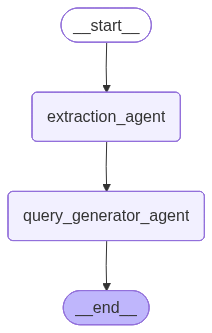

In [2]:
workflow

In [20]:
final_state = workflow.invoke({
    "input_type": "pdf",
    'input_data': 'data/sample_pdf2.pdf',
    'file_name': 'sample_pdf2'})

print(final_state)

AttributeError: 'str' object has no attribute 'seek'